In [2]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm
from torchvision.transforms import functional as TF
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import display, Image as IPImage
import gc
import matplotlib.colors as mcolors
from torch.utils.data import Dataset, DataLoader
import torchaudio
import soundfile as sf
import librosa
from torchaudio.transforms import Resample
import os
import random
from IPython.display import Audio
from scipy.signal import gammatone, lfilter, butter, hilbert
from pathlib import Path
import math

In [3]:
import os
import random
import torch
from torch.utils.data import Dataset
import torchaudio
from torchaudio.transforms import Resample

class RandomChunkAudioDataset(Dataset):
    def __init__(self, audio_dir, chunk_size=3600, sample_rate=16000,
                 max_tries=10, min_rms=0.0, debug=False):
        self.chunk_size = chunk_size
        self.sample_rate = sample_rate
        self.max_tries = max_tries
        self.min_rms = min_rms
        self.debug = debug

        self.file_paths = [
            os.path.join(root, fname)
            for root, _, files in os.walk(audio_dir)
            for fname in files if fname.lower().endswith('.wav')
        ]
        if not self.file_paths:
            raise RuntimeError(f"No .wav files found in {audio_dir}")

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        for attempt in range(self.max_tries):
            file_path = random.choice(self.file_paths)
            try:
                waveform, sr = torchaudio.load(file_path)  # (C, T)
                if waveform.size(0) > 1:
                    waveform = waveform.mean(dim=0, keepdim=True)  # convert to mono
                if sr != self.sample_rate:
                    resample = Resample(sr, self.sample_rate)
                    waveform = resample(waveform)

                if waveform.size(1) < self.chunk_size:
                    if self.debug:
                        print(f"[skip] Short file: {file_path} ({waveform.size(1)} samples)")
                    continue

                start = random.randint(0, waveform.size(1) - self.chunk_size)
                chunk = waveform[:, start:start + self.chunk_size]

                rms = chunk.pow(2).mean().sqrt().item()
                if self.debug:
                    print(f"[check] {file_path}: RMS={rms:.6f}")
                if rms < self.min_rms:
                    if self.debug:
                        print(f"[skip] RMS below threshold: {rms:.6f}")
                    continue

                return chunk

            except Exception as e:
                if self.debug:
                    print(f"[error] Failed to load {file_path}: {e}")
                continue

        raise RuntimeError("Failed to sample valid audio after several attempts.")


In [4]:
def play_waveform(waveform, sample_rate=16000):
    if isinstance(waveform, torch.Tensor):
        waveform = waveform.detach().cpu().numpy()

    # If it's stereo or batched, reduce to 1D
    if waveform.ndim == 2:
        waveform = waveform[0]  # Take first channel

    return Audio(waveform, rate=sample_rate)

In [5]:
def plot_filters(W: torch.Tensor, n: int = 8):
    """Plot a grid of nxn filters from the weight matrix W."""
    W = W.detach().cpu()
    fig, axes = plt.subplots(n, n, figsize=(12, 12))
    for i in range(n):
        for j in range(n):
            idx = i * n + j
            if idx < W.size(0):
                axes[i, j].plot(W[idx].numpy())
            axes[i, j].axis('off')
    plt.tight_layout()
    plt.show()

In [6]:
def plot_cochleagram(sheet, fs=16000, f_low=100, f_high=12000, cmap='magma'):
    """
    sheet : ndarray [n_ch, n_samples]
    fs    : sampling rate (Hz)
    f_low, f_high : frequency bounds used in cochlea_mean_rate
    """
    n_ch, n_samples = sheet.shape
    extent = [0, n_samples / fs * 1000,  # time in ms
              f_low, f_high]             # freq in Hz (approx)

    plt.figure(figsize=(10, 4))
    plt.imshow(sheet, aspect='auto', origin='lower',
               extent=extent, cmap=cmap)
    plt.colorbar(label='Firing rate (spikes/s)')
    plt.xlabel('Time (ms)')
    plt.ylabel('Characteristic frequency (Hz)')
    plt.title('Cochleagram (mean-rate cochlear sheet)')
    plt.tight_layout()
    plt.show()

<Figure size 640x480 with 0 Axes>

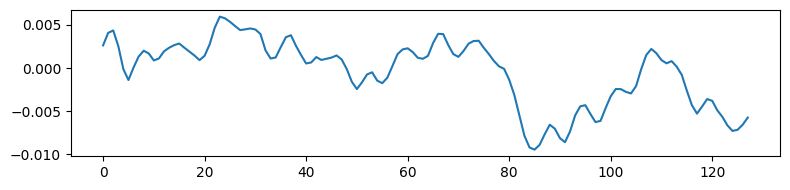

In [7]:
dataset = RandomChunkAudioDataset('./audio', chunk_size=128, sample_rate=16000, debug=False)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=640, shuffle=True)

for chunk in dataloader:
    signal = chunk[0, 0].numpy()

    plt.clf()            # Clear the current figure (important)
    plt.figure(figsize=(8, 2))
    plt.plot(signal)
    plt.tight_layout()
    plt.show()
    break

In [8]:
play_waveform(chunk[0])

In [9]:
# -------------------------
#  Model definition
# -------------------------

class SparseAutoencoder(nn.Module):
    def __init__(self, input_dim, n_channels):
        super().__init__()
        self.input_dim = input_dim
        self.n_channels = n_channels

        W = torch.rand(n_channels, input_dim)
        W /= W.sum(1, keepdim=True)
        self.W = nn.Parameter(W)
        self.W_t = nn.Parameter(torch.empty(input_dim, n_channels))
        nn.init.kaiming_uniform_(self.W_t, a=5**0.5)

    def forward(self, x):
        # x: (batch_size, input_dim)
        with torch.no_grad():
            self.W.div_(self.W.sum(dim=1, keepdim=True).clamp(min=1e-8))
        h = F.linear(x, self.W)  # (batch_size, n_channels)
        h_relu = torch.relu(h)

        x_hat = F.linear(h_relu, self.W_t)  # (batch_size, input_dim)
        return x_hat, h_relu

    # -------------------------
    #  Training loop
    # -------------------------

    def make_centered_gaussians(self,batch_size, channels):
        center = channels // 2
        sigma = (center) / math.sqrt(-2 * math.log(0.05))  # so that exp(-0.5 * (x/sigma)^2) = 0.05 at x = center
        x = torch.arange(channels, device=device).float()
        gaussian = torch.exp(-0.5 * ((x - center) / sigma) ** 2)  # shape: [C]
        gaussian = gaussian / gaussian.max()  # normalize peak to 1
    
        return gaussian.repeat(batch_size, 1)  # shape: [B, C]

    
    def train(self):
        # Parameters
        data_dir = './data'  # path to your wav files
        batch_size = 256
        learning_rate = 1e-3
        num_epochs = 20
        l1_weight = 1e-2
    
        dataset = RandomChunkAudioDataset('./audio', chunk_size=self.input_dim, sample_rate=16000, debug=False)
        dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
        optimizer = torch.optim.Adam(self.parameters(), lr=learning_rate)
    
        for epoch in range(num_epochs):
            total_loss = 0.0
            for batch in dataloader:
                if isinstance(batch, (list, tuple)):
                    batch = batch[0]  # extract the waveform chunk
                batch = batch.to(device)
    
                x_hat, h = self.forward(batch)

                z = self.make_centered_gaussians(batch.shape[0], batch.shape[2])[:,None]

                mse_loss = F.mse_loss(x_hat*z, batch*z)
                l1_loss = l1_weight * h.abs().mean()
                mean = h.mean(0, keepdim=True)
                homeo = (h.mean(-1, keepdim=True) - h)**2
                loss = mse_loss + l1_loss + homeo.mean() * 1e-2
    
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
    
                total_loss += loss.item() * batch.size(0)
    
            avg_loss = total_loss / len(dataloader.dataset)
            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.6f}")

In [10]:
input_dim = 64
n_channels = 32
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SparseAutoencoder(input_dim=input_dim, n_channels=n_channels).to(device)
model.train()

/home/nicolamendini/jupyter_env/lib/python3.12/site-packages/torch/cuda/__init__.py:174: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


Epoch 1/20, Loss: 0.006782
Epoch 2/20, Loss: 0.005927
Epoch 3/20, Loss: 0.006181
Epoch 4/20, Loss: 0.004899
Epoch 5/20, Loss: 0.005796
Epoch 6/20, Loss: 0.004852
Epoch 7/20, Loss: 0.004488
Epoch 8/20, Loss: 0.004646
Epoch 9/20, Loss: 0.004940


KeyboardInterrupt: 

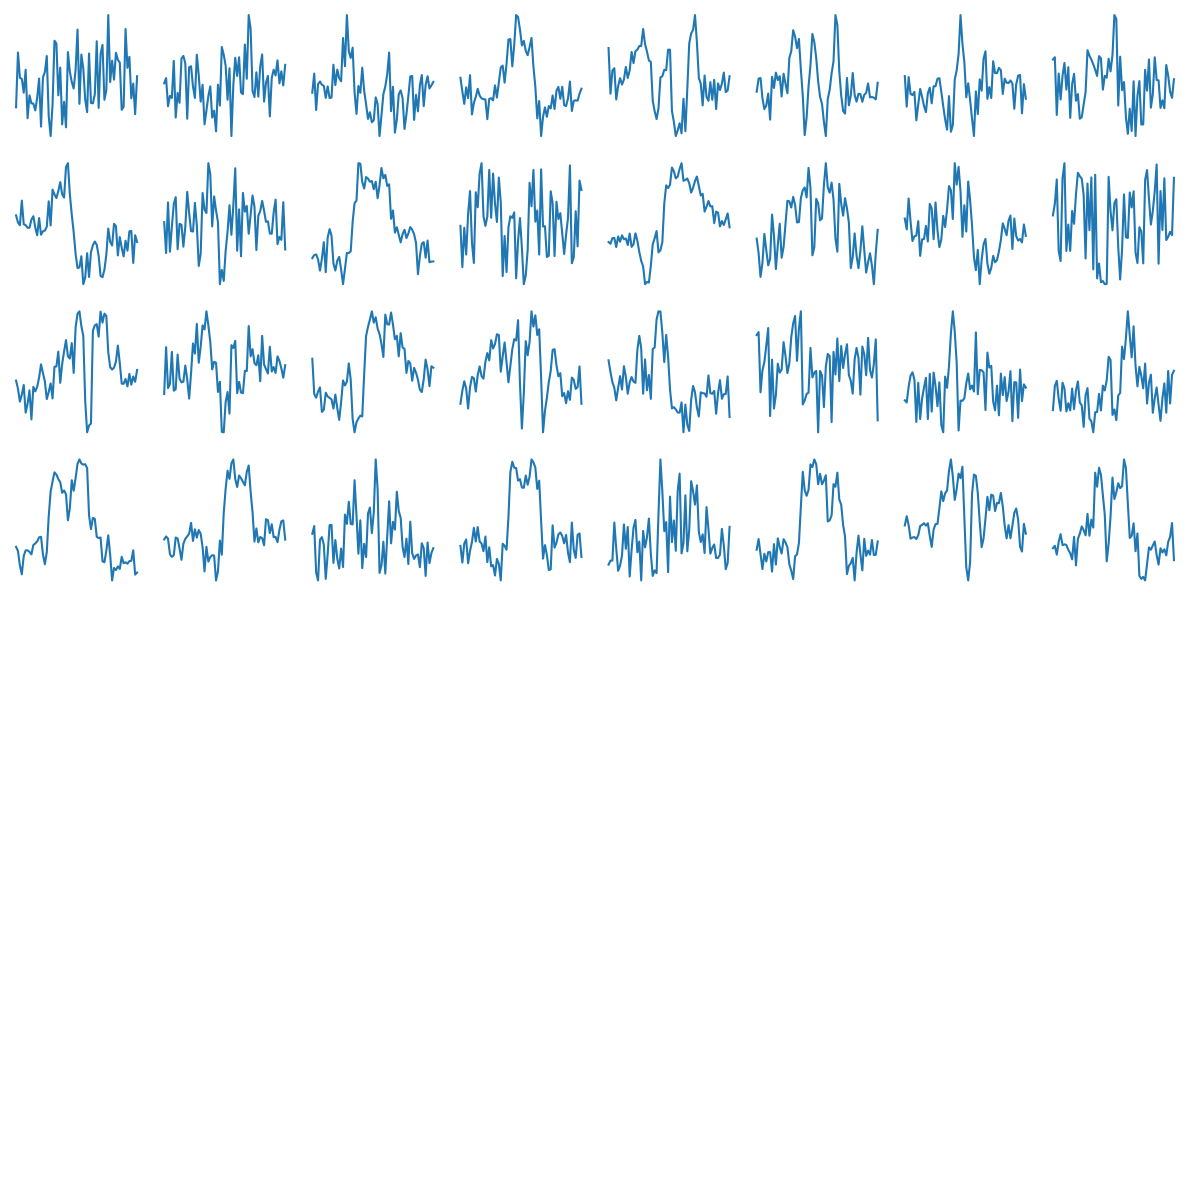

In [11]:
plot_filters(model.W)

In [176]:
from sklearn.decomposition import FastICA
import torch

def pre_emphasis(x, coef=0.97):
    return x[:, 1:] - coef * x[:, :-1]

# Suppose you have a batch of waveforms [num_samples, 128]
raw_data = chunk[:,0]

# Raw data: X ∈ [N, 128]
X = torch.tensor(raw_data).float()  # or from DataLoader

# High-pass
X = pre_emphasis(X)                 # shape [N, 127]

# Center each row
X = X - X.mean(dim=1, keepdim=True)

# Normalize per row (optional but often helps)
X = X / (X.norm(dim=1, keepdim=True) + 1e-8)

# Convert to NumPy
X_np = X.numpy()

# Run ICA
ica = FastICA(n_components=127, whiten='unit-variance', max_iter=1000, random_state=0)
S = ica.fit_transform(X_np)     # Independent components (source estimates)
A = ica.mixing_                 # Mixing matrix
W = ica.components_             # Unmixing matrix (filters)

# Back to torch if needed
W_torch = torch.from_numpy(W)

/tmp/ipykernel_41186/2281570953.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(raw_data).float()  # or from DataLoader


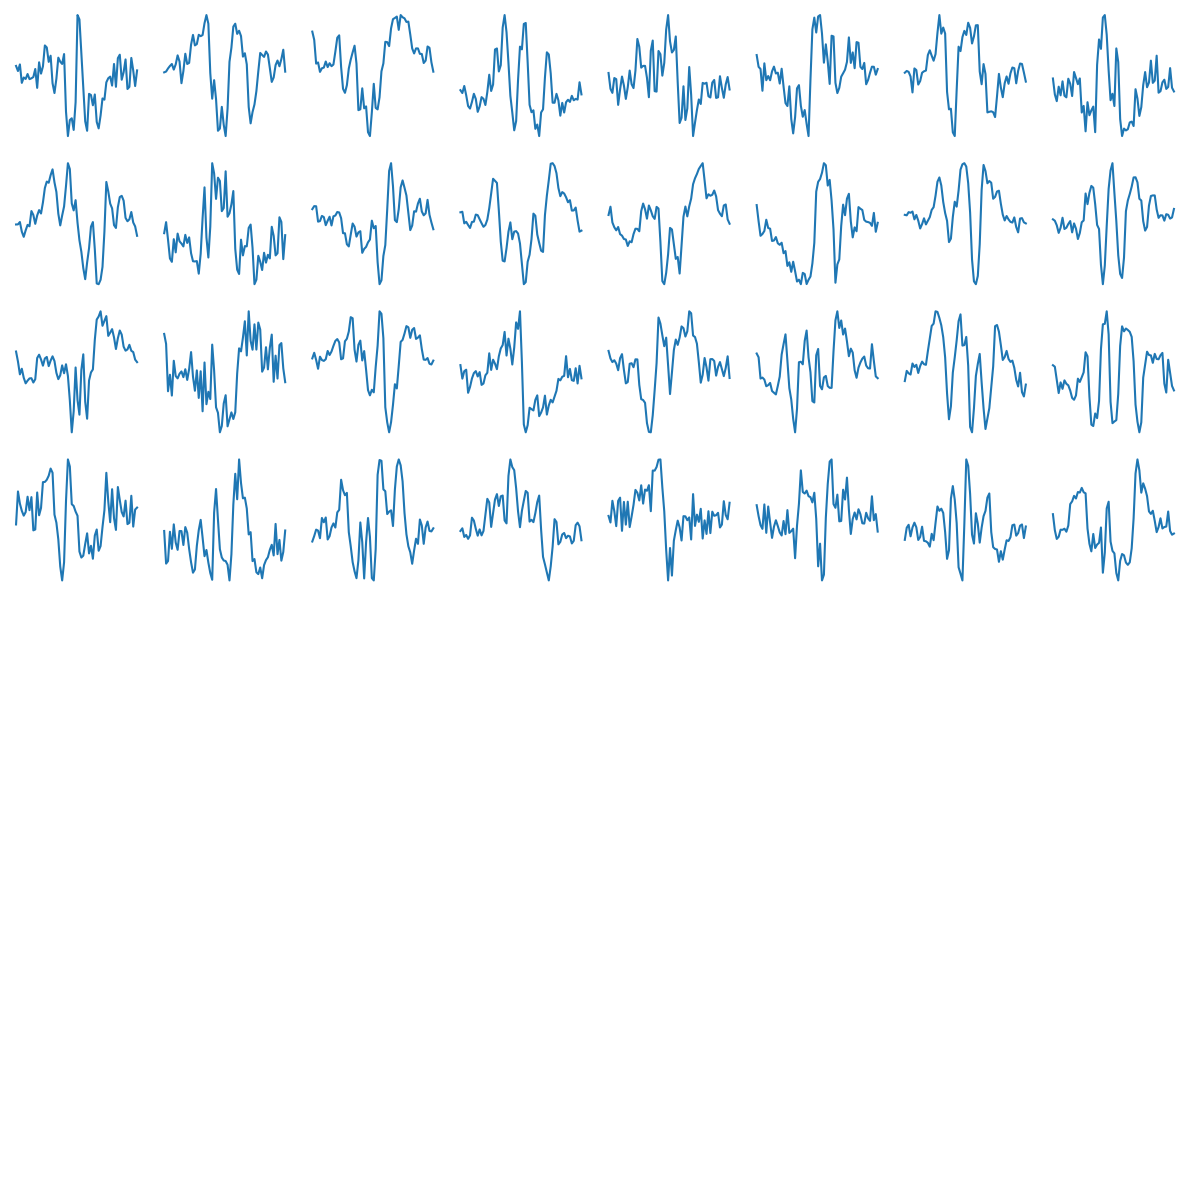

In [177]:
plot_filters(model.W)

In [178]:
# efficient_ica.py
import numpy as np
from scipy import linalg
from pathlib import Path

# ------------------------------------------------------------
# helpers
# ------------------------------------------------------------
def whiten(X):
    """Zero-mean and sphering (PCA whitening)."""
    X = X - X.mean(axis=0, keepdims=True)
    cov = X.T @ X / X.shape[0]
    D, E = np.linalg.eigh(cov)                # eigen-decomp
    Wwhite = (E / np.sqrt(D)).T               # whitening matrix  (D diag, E cols = eigen-vecs)
    return X @ Wwhite.T, Wwhite               # whitened data, whitening matrix

def sym_decorrelate(W):
    """W ← (W Wᵀ)^{-½} W   (Amari, ‘96)."""
    s, u = np.linalg.eigh(W @ W.T)
    return (u @ np.diag(1.0 / np.sqrt(s)) @ u.T) @ W

# ------------------------------------------------------------
# main ICA routine
# ------------------------------------------------------------
def efficient_ica(X,
                  n_components=128,
                  q_init=0.5,
                  lr0=1e-1,
                  lr_end=1e-5,
                  n_iters=20000,
                  q_update_every=500,
                  eps_q=1e-3,
                  seed=0):
    """
    Lewicki-style ICA with per-component generalized-Gaussian priors p(a) ∝ exp(-|a|^q).
    Returns the learned filter bank H (shape [n_components, n_samples]).
    """
    rng = np.random.default_rng(seed)
    Xw, Wwhite = whiten(X)                    # shape [batch, n_samples]
    batch, n_samples = Xw.shape

    # initialise unmixing matrix W  ~  O(n_components)
    W = rng.standard_normal((n_components, n_samples))
    W = sym_decorrelate(W)

    # per-component shape parameters q_i
    q = np.full((n_components, 1), q_init)

    # learning-rate schedule (linear decay)
    lrs = np.linspace(lr0, lr_end, n_iters)

    for t in range(n_iters):
        Y = (W @ Xw.T)                        # shape [n_components, batch]

        # φ(y) = -∂ log p / ∂y   for generalized Gaussian
        phi = -q * np.sign(Y) * np.abs(Y)**(q - 1)

        dW = (phi @ Y.T) / batch + np.linalg.inv(W.T)   # gradient ascent
        W += lrs[t] * dW
        W = sym_decorrelate(W)

        # -------- update q_i every few iterations ----------
        if (t + 1) % q_update_every == 0:
            absY = np.abs(Y)
            # MLE for q solves:  E[|y|^q log|y|] / E[|y|^q]  = 1/q + ψ(1/q)/np.log
            # use fixed-point Newton (one step suffices in practice)
            m1 = absY.mean(axis=1, keepdims=True)
            m2 = (absY * np.log(absY + 1e-12)).mean(axis=1, keepdims=True)
            q_new = 1.0 / ( (m2 / (m1 + 1e-12)) - np.log(m1 + 1e-12) )
            # clamp to [0.3,3] to keep gradients stable
            q = np.clip(0.3 * q + 0.7 * q_new, 0.35, 2.5)

            # (optional) stop updating if change is tiny
            if np.max(np.abs(q_new - q)) < eps_q and t > n_iters//2:
                q_update_every = 2000         # slow down q updates

    # --------------------------------------------------------
    # filters are rows of W⁻¹ = (Wwhiteᵀ W)⁻¹
    # For analysis we usually want FIR filters in *forward* sense: H = W⁻¹ Wwhite⁻¹
    # Because Xw = X @ Wwhiteᵀ, and Y = W Xwᵀ = W Wwhite Xᵀ
    H = linalg.lu_inverse(linalg.lu_factor(W)) @ linalg.lu_inverse(linalg.lu_factor(Wwhite))
    return H                      # shape [n_components, n_samples]


In [181]:
# Load any ~5-10 s WAV (mono) and cut 640×128 segments


filters = efficient_ica(chunk[:,0].numpy())   # returns 128 filters, each 128 samples long

AttributeError: module 'scipy.linalg' has no attribute 'lu_inverse'